In [1]:
# ==========================================
# 1. SETUP ENVIRONMENT & REPRODUCIBILITY
# ==========================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings

warnings.filterwarnings('ignore')

# Thiết lập Random Seed cố định
RANDOM_SEED = 42
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Libraries for House Price Prediction imported successfully!")

Libraries for House Price Prediction imported successfully!


In [2]:
# ==========================================
# 2. PROBLEM DEFINITION & DATASET LOADING
# ==========================================
DATA_PATH = "../data/house_price.csv"

df = pd.read_csv(DATA_PATH)
print("Data Shape:", df.shape)

# Lựa chọn tập đặc trưng đại diện chính từ 81 cột để mô hình gọn nhẹ và hiệu quả
selected_num_cols = ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'YearBuilt', 'GarageCars', 'LotArea']
selected_cat_cols = ['MSZoning', 'Neighborhood', 'HouseStyle']
target_col = 'SalePrice'

# Giữ lại các cột cần thiết + loại bỏ cột Id
df = df[selected_num_cols + selected_cat_cols + [target_col]]
print("Selected Data Shape:", df.shape)
df.head()

Data Shape: (1460, 81)
Selected Data Shape: (1460, 10)


,GrLivArea,BedroomAbvGr,FullBath,YearBuilt,GarageCars,LotArea,MSZoning,Neighborhood,HouseStyle,SalePrice
0,1710,3,2,2003,2,8450,RL,CollgCr,2Story,208500
1,1262,3,2,1976,2,9600,RL,Veenker,1Story,181500
2,1786,3,2,2001,2,11250,RL,CollgCr,2Story,223500
3,1717,3,1,1915,3,9550,RL,Crawfor,2Story,140000
4,2198,4,2,2000,3,14260,RL,NoRidge,2Story,250000


In [3]:
# ==========================================
# 3. DATA INSPECTION & QUALITY ANALYSIS
# ==========================================
print("--- INFO ---")
print(df.info())

print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

print("\n--- MISSING VALUES ---")
print(df.isna().sum())

print("\n--- DUPLICATE RECORDS ---")
print(f"Duplicated records: {df.duplicated().sum()}")

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   GrLivArea     1460 non-null   int64
 1   BedroomAbvGr  1460 non-null   int64
 2   FullBath      1460 non-null   int64
 3   YearBuilt     1460 non-null   int64
 4   GarageCars    1460 non-null   int64
 5   LotArea       1460 non-null   int64
 6   MSZoning      1460 non-null   str  
 7   Neighborhood  1460 non-null   str  
 8   HouseStyle    1460 non-null   str  
 9   SalePrice     1460 non-null   int64
dtypes: int64(7), str(3)
memory usage: 134.8 KB
None

--- STATISTICAL SUMMARY ---


,GrLivArea,BedroomAbvGr,FullBath,YearBuilt,GarageCars,LotArea,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,1515.463699,2.866438,1.565068,1971.267808,1.767123,10516.828082,180921.195890
std,525.480383,0.815778,0.550916,30.202904,0.747315,9981.264932,79442.502883
min,334.000000,0.000000,0.000000,1872.000000,0.000000,1300.000000,34900.000000
25%,1129.500000,2.000000,1.000000,1954.000000,1.000000,7553.500000,129975.000000
50%,1464.000000,3.000000,2.000000,1973.000000,2.000000,9478.500000,163000.000000
75%,1776.750000,3.000000,2.000000,2000.000000,2.000000,11601.500000,214000.000000
max,5642.000000,8.000000,3.000000,2010.000000,4.000000,215245.000000,755000.000000



--- MISSING VALUES ---
GrLivArea       0
BedroomAbvGr    0
FullBath        0
YearBuilt       0
GarageCars      0
LotArea         0
MSZoning        0
Neighborhood    0
HouseStyle      0
SalePrice       0
dtype: int64

--- DUPLICATE RECORDS ---
Duplicated records: 1


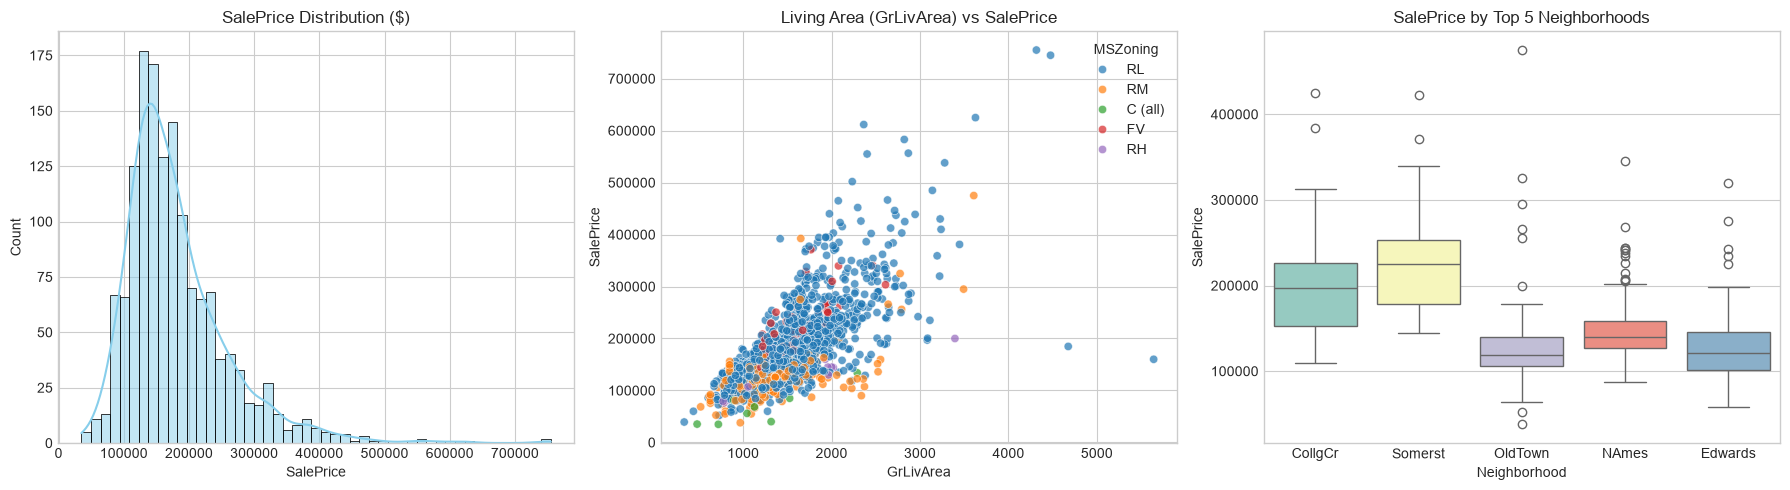


--- EDA INSIGHTS & EXPLANATIONS ---
1. SalePrice Distribution:
   - Observation: Giá nhà có độ lệch phải (Right-skewed), tập trung nhiều ở phân khúc 100,000$ - 250,000$.
   - Interpretation: Phần lớn giao dịch là nhà ở phân khúc tầm trung.
   - ML Implication: Mô hình dựa trên Cây (Tree-based) hoặc Ridge Regression sẽ chống chọi tốt với phân bố này.

2. Living Area vs SalePrice:
   - Observation: Diện tích mặt sàn trên mặt đất (GrLivArea) có tương quan thuận rất mạnh với SalePrice.
   - Interpretation: Diện tích sinh hoạt là yếu tố quan trọng bậc nhất định giá căn nhà.
   - ML Implication: Cột GrLivArea sẽ mang điểm Feature Importance cao nhất trong mô hình.

3. SalePrice by Neighborhood:
   - Observation: Mức giá trung bình giữa các khu vực (Neighborhood) có sự chênh lệch rõ rệt.
   - Interpretation: Vị trí địa lý quyết định trực tiếp tới giá trị bất động sản.
   - ML Implication: Cần dùng One-Hot Encoding cho biến Neighborhood để mô hình học được giá trị vị trí.



In [4]:
# ==========================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Target Distribution (SalePrice)
sns.histplot(data=df, x='SalePrice', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('SalePrice Distribution ($)')

# Plot 2: Living Area (GrLivArea) vs SalePrice
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', hue='MSZoning', ax=axes[1], alpha=0.7)
axes[1].set_title('Living Area (GrLivArea) vs SalePrice')

# Plot 3: SalePrice by Neighborhood (Top 5 popular)
top_neighborhoods = df['Neighborhood'].value_counts().head(5).index
sns.boxplot(data=df[df['Neighborhood'].isin(top_neighborhoods)], x='Neighborhood', y='SalePrice', ax=axes[2], palette='Set3')
axes[2].set_title('SalePrice by Top 5 Neighborhoods')

plt.tight_layout()
plt.show()

print("""
--- EDA INSIGHTS & EXPLANATIONS ---
1. SalePrice Distribution:
   - Observation: Giá nhà có độ lệch phải (Right-skewed), tập trung nhiều ở phân khúc 100,000$ - 250,000$.
   - Interpretation: Phần lớn giao dịch là nhà ở phân khúc tầm trung.
   - ML Implication: Mô hình dựa trên Cây (Tree-based) hoặc Ridge Regression sẽ chống chọi tốt với phân bố này.

2. Living Area vs SalePrice:
   - Observation: Diện tích mặt sàn trên mặt đất (GrLivArea) có tương quan thuận rất mạnh với SalePrice.
   - Interpretation: Diện tích sinh hoạt là yếu tố quan trọng bậc nhất định giá căn nhà.
   - ML Implication: Cột GrLivArea sẽ mang điểm Feature Importance cao nhất trong mô hình.

3. SalePrice by Neighborhood:
   - Observation: Mức giá trung bình giữa các khu vực (Neighborhood) có sự chênh lệch rõ rệt.
   - Interpretation: Vị trí địa lý quyết định trực tiếp tới giá trị bất động sản.
   - ML Implication: Cần dùng One-Hot Encoding cho biến Neighborhood để mô hình học được giá trị vị trí.
""")

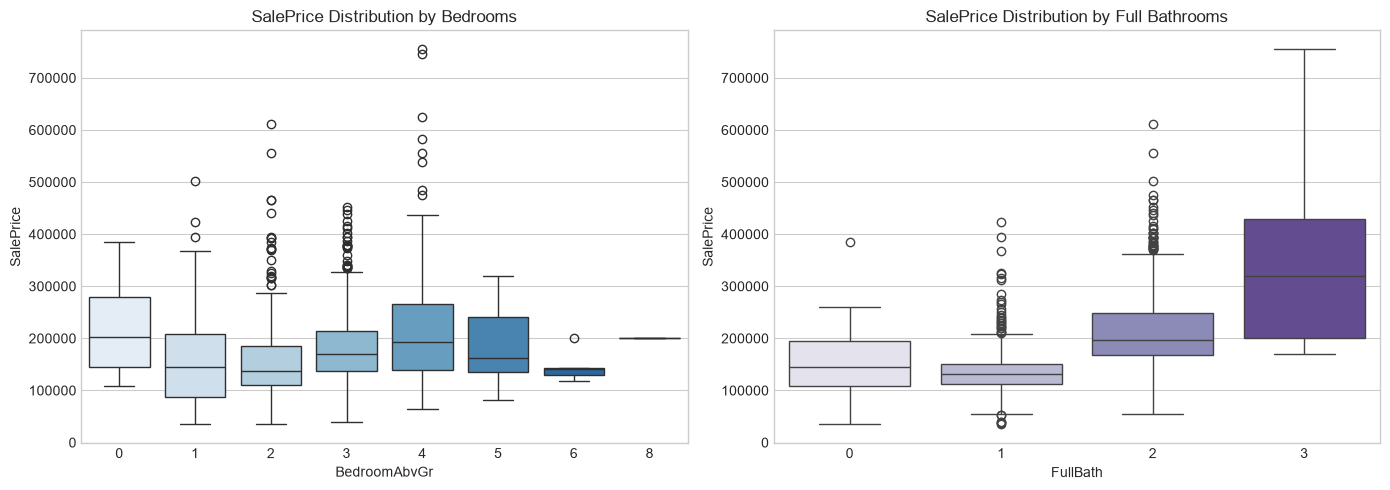


--- EXTENSIVE EDA INSIGHTS ---
- Bedrooms Impact: Giá nhà tăng dần theo số lượng phòng ngủ từ 1 đến 4 phòng, sau đó bão hòa ở các căn có nhiều phòng hơn.
- Bathrooms Impact: Số lượng phòng tắm đầy đủ (Full Bath) có tương quan rất mạnh với giá nhà, các nhà có 3 phòng tắm đạt mức giá trung bình vượt trội.



In [5]:
# ==========================================
# 4B. EXTENSIVE EDA - BEDROOMS & BATHROOMS VS PRICE
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Price by Bedrooms
sns.boxplot(data=df, x='BedroomAbvGr', y='SalePrice', ax=axes[0], palette='Blues')
axes[0].set_title('SalePrice Distribution by Bedrooms')

# 2. Price by Full Bathrooms
sns.boxplot(data=df, x='FullBath', y='SalePrice', ax=axes[1], palette='Purples')
axes[1].set_title('SalePrice Distribution by Full Bathrooms')

plt.tight_layout()
plt.show()

print("""
--- EXTENSIVE EDA INSIGHTS ---
- Bedrooms Impact: Giá nhà tăng dần theo số lượng phòng ngủ từ 1 đến 4 phòng, sau đó bão hòa ở các căn có nhiều phòng hơn.
- Bathrooms Impact: Số lượng phòng tắm đầy đủ (Full Bath) có tương quan rất mạnh với giá nhà, các nhà có 3 phòng tắm đạt mức giá trung bình vượt trội.
""")

In [6]:
# ==========================================
# 5. DATA REPRESENTATION & PREPROCESSING
# ==========================================
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

N, d_raw = X.shape
print(f"Raw Feature Matrix: X in R^({N} x {d_raw})")

# Chia Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)

# Pipeline tiền xử lý
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, selected_num_cols),
        ('cat', cat_transformer, selected_cat_cols)
    ]
)

# Fit CHỈ TRÊN X_train
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"Processed Input Matrix Shape (X_train_prep): {X_train_prep.shape}")

Raw Feature Matrix: X in R^(1460 x 9)
Processed Input Matrix Shape (X_train_prep): (1168, 44)


In [7]:
# ==========================================
# 6. MODEL DEVELOPMENT & COMPARISON
# ==========================================
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=RANDOM_SEED),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=RANDOM_SEED),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=RANDOM_SEED)
}

results = []

for name, model in models.items():
    model.fit(X_train_prep, y_train)
    y_pred = model.predict(X_test_prep)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MAE ($)': round(mae, 2),
        'MSE': round(mse, 2),
        'RMSE ($)': round(rmse, 2),
        'R² Score': round(r2, 4)
    })

df_results = pd.DataFrame(results)
display(df_results)

,Model,MAE ($),MSE,RMSE ($),R² Score
0,Linear Regression,24555.24,1.483455e+09,38515.64,0.8066
1,Ridge Regression,24520.14,1.486678e+09,38557.46,0.8062
2,Decision Tree Regressor,26220.33,1.773312e+09,42110.72,0.7688
3,Random Forest Regressor,19722.04,8.996029e+08,29993.38,0.8827
4,Gradient Boosting Regressor,20943.79,9.094162e+08,30156.53,0.8814


Selected Best Model: Random Forest Regressor


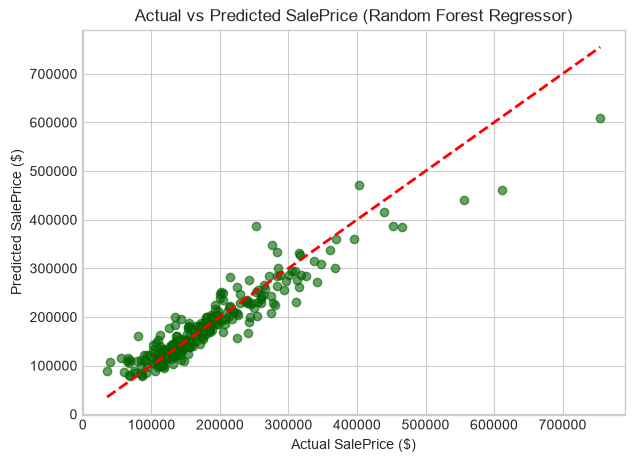


--- EVALUATION SUMMARY ---
- Mô hình xuất sắc nhất: Random Forest Regressor
- R² Score: 0.8827
- RMSE: $29,993.38



In [8]:
# ==========================================
# 7. EVALUATION & BEST MODEL SELECTION
# ==========================================
best_model_name = df_results.sort_values(by='R² Score', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]

print(f"Selected Best Model: {best_model_name}")

y_pred_best = best_model.predict(X_test_prep)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual SalePrice ($)')
plt.ylabel('Predicted SalePrice ($)')
plt.title(f'Actual vs Predicted SalePrice ({best_model_name})')
plt.show()

print(f"""
--- EVALUATION SUMMARY ---
- Mô hình xuất sắc nhất: {best_model_name}
- R² Score: {df_results.loc[df_results['Model'] == best_model_name, 'R² Score'].values[0]}
- RMSE: ${df_results.loc[df_results['Model'] == best_model_name, 'RMSE ($)'].values[0]:,}
""")

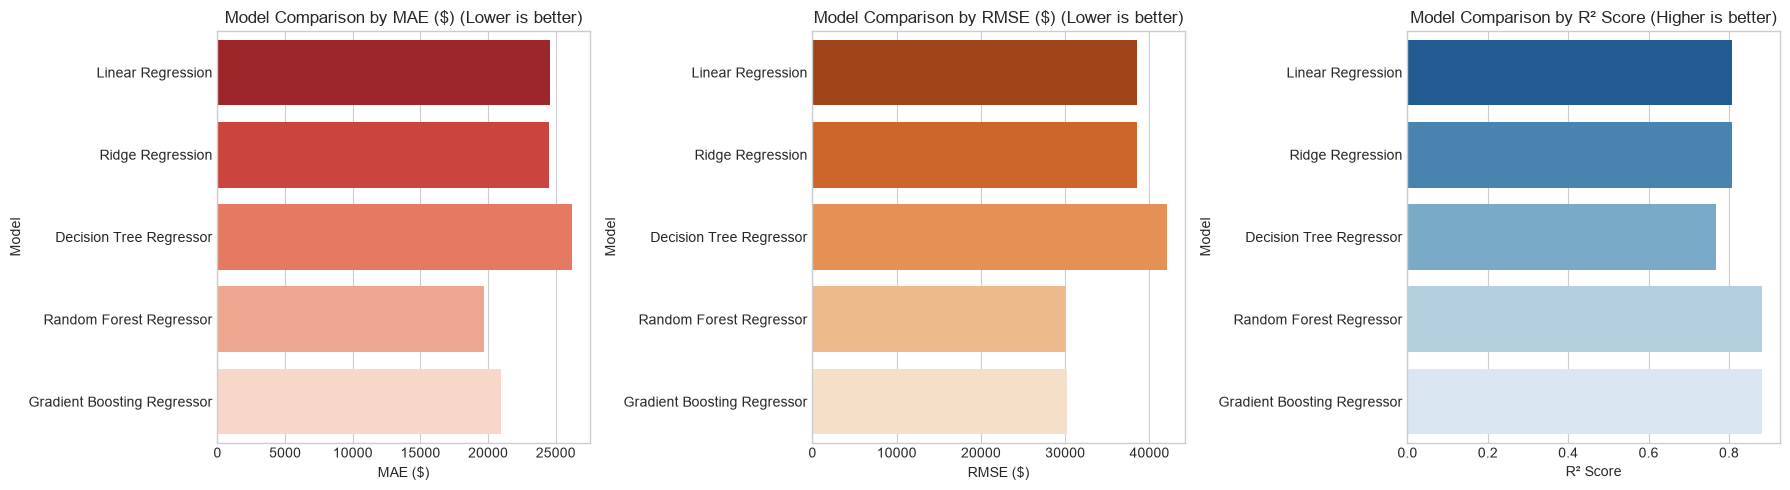

In [9]:
# ==========================================
# 7B. EXTENSIVE EVALUATION - REGRESSION METRICS COMPARISON
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. MAE Comparison (Thấp hơn là tốt hơn)
sns.barplot(data=df_results, x='MAE ($)', y='Model', palette='Reds_r', ax=axes[0])
axes[0].set_title('Model Comparison by MAE ($) (Lower is better)')

# 2. RMSE Comparison (Thấp hơn là tốt hơn)
sns.barplot(data=df_results, x='RMSE ($)', y='Model', palette='Oranges_r', ax=axes[1])
axes[1].set_title('Model Comparison by RMSE ($) (Lower is better)')

# 3. R2 Score Comparison (Cao hơn là tốt hơn)
sns.barplot(data=df_results, x='R² Score', y='Model', palette='Blues_r', ax=axes[2])
axes[2].set_title('Model Comparison by R² Score (Higher is better)')

plt.tight_layout()
plt.show()

In [10]:
# ==========================================
# 8. MODEL PERSISTENCE & INFERENCE TEST
# ==========================================
os.makedirs("../model", exist_ok=True)
PREPROCESSOR_PATH = "../model/preprocessor.joblib"
MODEL_PATH = "../model/model.joblib"

# 1. Lưu file .joblib
joblib.dump(preprocessor, PREPROCESSOR_PATH)
joblib.dump(best_model, MODEL_PATH)
print(f"Saved Preprocessor to {PREPROCESSOR_PATH}")
print(f"Saved Model to {MODEL_PATH}")

# 2. KIỂM THỬ INFERENCE TƯƠNG THÍCH VỚI KAGGLE DATASET
print("\n--- SIMULATING INFERENCE ON NEW UNSEEN HOUSE DATA ---")

new_house_raw = {
    'GrLivArea': 1710,
    'BedroomAbvGr': 3,
    'FullBath': 2,
    'YearBuilt': 2003,
    'GarageCars': 2,
    'LotArea': 8450,
    'MSZoning': 'RL',
    'Neighborhood': 'CollgCr',
    'HouseStyle': '2Story'
}

loaded_preprocessor = joblib.load(PREPROCESSOR_PATH)
loaded_model = joblib.load(MODEL_PATH)

df_new = pd.DataFrame([new_house_raw])
X_new_prep = loaded_preprocessor.transform(df_new)
predicted_price = loaded_model.predict(X_new_prep)[0]

result = {
    "predicted_price": round(float(predicted_price), 2),
    "currency": "USD"
}

print("Inference Output JSON:")
print(result)

Saved Preprocessor to ../model/preprocessor.joblib
Saved Model to ../model/model.joblib

--- SIMULATING INFERENCE ON NEW UNSEEN HOUSE DATA ---
Inference Output JSON:
{'predicted_price': 202609.0, 'currency': 'USD'}
